# Chapter 4 — Other Numerical Methods

*Python-native adaptation of Michael Honeychurch,
**Simulating Electrochemical Reactions in Mathematica** (SERM), Chapter 4
("Other numerical methods"). The original notebooks `RungeKutta.nb`, `SOR.nb`,
`Volterra1.nb` and `Volterra2.nb` are the reference for the algorithms; the code
here is an idiomatic numpy/scipy/matplotlib re-implementation, and every result
is re-derived and re-validated against an independent analytic reference.*

Chapters 2 and 3 reduced the diffusion problem to a tridiagonal matrix solved by
the Thomas algorithm. This chapter steps outside that mould and surveys three
alternative numerical methods that recur throughout electrochemical simulation:

1. **Runge–Kutta** — a higher-accuracy *explicit* time integrator for the
   parabolic diffusion PDE, an upgrade on the plain forward-Euler scheme of
   Chapter 2.
2. **Successive over-relaxation (SOR)** — an *iterative* linear solver for the
   implicit (backward-Euler) step, an alternative to a direct tridiagonal solve
   that generalises to problems where a direct factorisation is awkward.
3. **The Volterra integral-equation method (Huber's method)** — the route used
   when a Laplace-transform solution of an electrochemical problem leaves a
   convolution integral that must be inverted numerically. This is the classical
   way to compute a cyclic voltammogram *without* ever discretising space, and it
   is our strongest validation target: it reproduces the Randles–Ševčík peak.

Throughout we reuse the shared `serm` machinery (`serm.echem`, `serm.waveforms`)
for the independent analytic references rather than re-deriving them inline.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular

import serm
from serm import echem

np.set_printoptions(precision=6, suppress=True)

## 1. Runge–Kutta for the diffusion equation

### 1.1 The diffusion problem in dimensionless form

As in Chapter 2 we simulate a potential step into the diffusion-limited region
for $O + e^- \rightleftharpoons R$. In dimensionless variables Fick's second law
is

$$\frac{\partial c}{\partial \tau} = \frac{\partial^2 c}{\partial x^2},$$

with the centred second difference in space giving the semi-discrete system

$$\frac{\mathrm{d} c_j}{\mathrm{d}\tau}
   = D_M\,\bigl(c_{j-1} - 2c_j + c_{j+1}\bigr) \equiv g\!\left(c_j\right),$$

where $D_M = \Delta\tau/\Delta x^2$ is the model diffusion coefficient. The plain
explicit scheme of Chapter 2 takes a single forward-Euler step of this ODE
system. A second-order Runge–Kutta (RK2) method takes a *better* step.

### 1.2 Deriving second-order Runge–Kutta

Honeychurch derives RK2 by Taylor-expanding $f(t\pm\Delta t)$ about the midpoint
$t+\Delta t/2$ and eliminating the second derivative. The result is the midpoint
method: to advance $\mathrm{d}f/\mathrm{d}t = g(f)$ by one step,

$$k_1 = \Delta t\,g\bigl(f(t)\bigr), \qquad
  k_2 = \Delta t\,g\!\left(f(t) + \tfrac{1}{2}k_1\right), \qquad
  f(t+\Delta t) = f(t) + k_2.$$

Evaluating the slope at the midpoint (using the half-step prediction $f+\tfrac12 k_1$)
cancels the leading $O(\Delta t^2)$ error of forward Euler, so the local error is
$O(\Delta t^3)$ and the method is globally second order in time.

Because our $g$ is *linear* — it is the discrete Laplacian — we can write the
step compactly. With $L$ the three-point Laplacian operator scaled by $D_M$,
$k_1 = L c$ and $k_2 = L\!\left(c + \tfrac12 k_1\right) = k_1 + \tfrac12 L k_1$, so

$$c^{k+1} = c^{k} + k_1 + \tfrac12 L k_1 .$$

This is exactly the SERM `rungeKuttaSolve` routine, which applies the Laplacian
stencil $[D_M,\,-2D_M,\,D_M]$ twice via `ListCorrelate`. We reproduce it with two
applications of `np.convolve`.

In [2]:
def laplacian(c: np.ndarray, D_M: float) -> np.ndarray:
    """Apply the scaled discrete Laplacian D_M (c[j-1]-2c[j]+c[j+1]).

    Returns an array of length ``len(c)-2`` (the interior nodes), matching the
    SERM ``ListCorrelate[{D_M,-2 D_M, D_M}, c]`` convention.
    """
    stencil = np.array([D_M, -2.0 * D_M, D_M])
    return np.convolve(c, stencil[::-1], mode="valid")


def rk2_step(c: np.ndarray, D_M: float) -> np.ndarray:
    """One midpoint (RK2) step of the dimensionless diffusion equation.

    Port of ``rungeKuttaSolve`` (RungeKutta.nb). The surface node is pinned to
    0 (diffusion-limited step) and the outer node to the bulk value 1.

    Parameters
    ----------
    c : ndarray, shape (m,)
        Full concentration vector including both boundary nodes.
    D_M : float
        Dimensionless model diffusion coefficient.

    Returns
    -------
    ndarray, shape (m,)
        Concentration after one RK2 time step, boundaries re-applied.
    """
    full = c.copy()
    full[0] = 0.0       # surface: diffusion-limited
    full[-1] = 1.0      # bulk
    k1 = laplacian(full, D_M)                       # interior, length m-2
    padded = np.concatenate(([0.0], 0.5 * k1, [0.0]))
    k2_correction = laplacian(padded, D_M)          # 1/2 L k1, length m-2
    out = full.copy()
    out[1:-1] = full[1:-1] + k1 + k2_correction
    out[0] = 0.0
    out[-1] = 1.0
    return out


def rk2_solve(D_M: float, n_steps: int) -> np.ndarray:
    """Integrate the diffusion-limited potential step with RK2.

    The grid width follows the SERM rule ``m = 1 + ceil(6 sqrt(D_M (n-1)))`` so
    the diffusion layer never reaches the outer boundary.

    Returns
    -------
    ndarray, shape (n_steps, m)
        Concentration grid; row ``k`` is the profile after ``k+1`` time steps.
    """
    m = 1 + int(np.ceil(6.0 * np.sqrt(D_M * (n_steps - 1))))
    c = np.ones(m)
    c[0] = 0.0
    history = np.empty((n_steps, m))
    for k in range(n_steps):
        c = rk2_step(c, D_M)
        history[k] = c
    return history

### 1.3 Current and the Cottrell check

The dimensionless current is the concentration gradient at the electrode. SERM
uses the same one-sided three-point derivative as Chapter 2,

$$i^k = \tfrac12\bigl(-4 c_1^k + c_2^k\bigr)\sqrt{D_M (n-1)},$$

(with the surface node $c_0=0$). For a step to the diffusion-limited region the
exact answer is the **Cottrell** decay; in these dimensionless variables, with
$\tau = (k-1)/(n-1)$, that is $i(\tau) = -1/\sqrt{\pi\tau}$ (the sign is the
reduction convention). We compute both and overlay them.

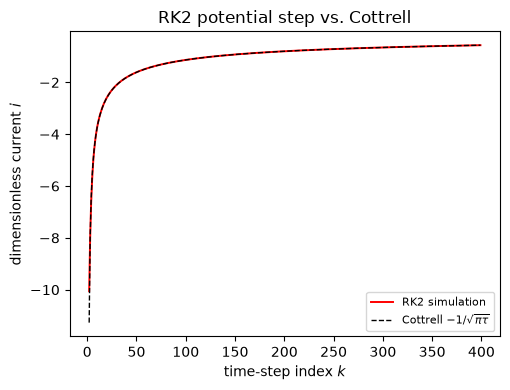

In [3]:
D_M = 0.4
N_STEPS = 400

hist_rk = rk2_solve(D_M, N_STEPS)
factor = 0.5 * np.sqrt(D_M * (N_STEPS - 1))
i_rk = (-4.0 * hist_rk[:, 1] + hist_rk[:, 2]) * factor   # signed (negative)

# Dimensionless Cottrell reference on the same tau grid (k = 2 .. n-1).
k_idx = np.arange(2, N_STEPS)
tau = (k_idx - 1) / (N_STEPS - 1)
i_cottrell = -1.0 / np.sqrt(np.pi * tau)

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.plot(k_idx, i_rk[1:N_STEPS - 1], "r-", lw=1.4, label="RK2 simulation")
ax.plot(k_idx, i_cottrell, "k--", lw=1.0, label=r"Cottrell $-1/\sqrt{\pi\tau}$")
ax.set_xlabel("time-step index $k$")
ax.set_ylabel("dimensionless current $i$")
ax.set_title("RK2 potential step vs. Cottrell")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 2. Successive over-relaxation for the implicit step

### 2.1 The implicit step as a linear system

The Chapter 2 *implicit* (backward-Euler / BTCS) discretisation advances the
profile by solving, at every time level, a tridiagonal system $A\,c^{k} = b$
with

$$A = \mathrm{tridiag}(-D_M,\; 1+2D_M,\; -D_M), \qquad b = c^{k-1},$$

where $c^{k-1}$ is the previous profile (and the known boundary contributions are
folded into $b$). Chapters 2–3 solve this directly with the Thomas algorithm.
SOR solves it instead by **iteration**, which is the method of choice when the
matrix is large, sparse, or not conveniently tridiagonal.

### 2.2 Jacobi → Gauss–Seidel → SOR

Write row $i$ of $A c = b$ as $y_i c_i + x_i c_{i-1} + z_i c_{i+1} = b_i$ and
solve for $c_i$:

$$c_i^{*} = \frac{b_i - x_i c_{i-1} - z_i c_{i+1}}{y_i}.$$

- **Jacobi**: use *old* neighbour values everywhere; convergence is slow,
  scaling like the square of the system size.
- **Gauss–Seidel**: use freshly updated neighbours $c_{i-1}$ as soon as they are
  available — roughly twice as fast.
- **SOR**: over-correct the Gauss–Seidel update by a relaxation factor
  $\omega \in (1,2)$,

  $$c_i^{\text{new}} = c_i^{\text{old}} + \omega\,\bigl(c_i^{*} - c_i^{\text{old}}\bigr).$$

For the 1-D diffusion matrix SERM uses the near-optimal estimate

$$\omega \approx \frac{2}{1 + \pi/(m-2)},$$

with $m-2$ the number of interior unknowns. Iteration stops when the squared
residual $\lVert c^{\text{new}} - c^{\text{old}}\rVert^2$ falls below $\varepsilon^2$.
This is a direct port of the `SOR` / `SORSolve` routines in `SOR.nb`.

In [4]:
def sor_solve_step(b: np.ndarray, D_M: float, omega: float,
                   eps: float = 1e-9, max_iter: int = 100_000) -> np.ndarray:
    """Solve one implicit (BTCS) tridiagonal step by SOR.

    Solves ``A c = b`` for the interior nodes, where ``A`` has sub/super
    diagonal ``-D_M`` and main diagonal ``1 + 2 D_M``. The right boundary
    contributes the known bulk value (``c = 1``) to the last equation, exactly
    as in the SERM ``SOR`` routine (the ``z[i]`` term with no neighbour).

    Parameters
    ----------
    b : ndarray, shape (len_,)
        Right-hand side (the previous interior profile).
    D_M, omega, eps :
        Model diffusion coefficient, relaxation factor, residual tolerance.

    Returns
    -------
    ndarray, shape (len_,)
        Converged interior profile.
    """
    lo, di, up = -D_M, 1.0 + 2.0 * D_M, -D_M
    n = b.shape[0]
    c_old = b.copy()
    for _ in range(max_iter):
        c_new = c_old.copy()
        for i in range(n):
            left = lo * c_new[i - 1] if i > 0 else 0.0
            # last interior node: the super-diagonal neighbour is the bulk (c=1),
            # so the contribution is just ``up`` (SERM: z[i] with no c[i+1]).
            right = up * c_old[i + 1] if i < n - 1 else up
            c_star = (b[i] - left - right) / di
            c_new[i] = c_old[i] + omega * (c_star - c_old[i])
        if np.sum((c_new - c_old) ** 2) < eps ** 2:
            return c_new
        c_old = c_new
    raise RuntimeError("SOR did not converge within max_iter iterations")


def sor_solve(D_M: float, n_steps: int, eps: float = 1e-9) -> np.ndarray:
    """Integrate the diffusion-limited potential step implicitly via SOR.

    Returns
    -------
    ndarray, shape (n_steps, m)
        Concentration grid (full profiles including both boundaries).
    """
    m = int(np.ceil(6.0 * np.sqrt(D_M * (n_steps - 1))))
    n_interior = m - 2
    omega = 2.0 / (1.0 + np.pi / n_interior)
    interior = np.ones(n_interior)
    history = np.empty((n_steps, m))
    for k in range(n_steps):
        interior = sor_solve_step(interior, D_M, omega, eps)
        history[k] = np.concatenate(([0.0], interior, [1.0]))
    return history

### 2.3 SOR results: Cottrell agreement and a direct cross-check

We run the implicit step with $D_M = 0.5$ (an unconditionally stable choice for
the implicit scheme — forward Euler would be on its stability edge here) and
compare the current to Cottrell. As a second, independent check we re-solve the
*same* linear system at one time level with a direct banded Thomas solve
(`serm.tridiagonal.tridiag_solve_banded`) and confirm SOR reproduces it.

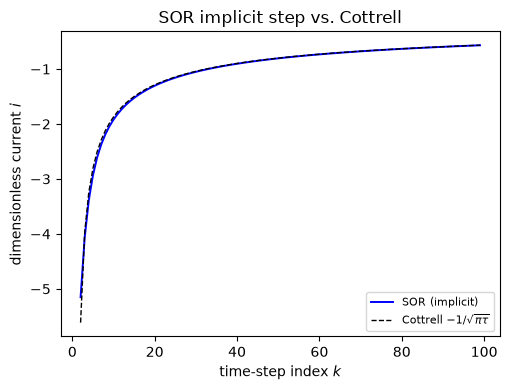

In [5]:
D_M_SOR = 0.5
N_STEPS_SOR = 100

hist_sor = sor_solve(D_M_SOR, N_STEPS_SOR)
factor_sor = 0.5 * np.sqrt(D_M_SOR * (N_STEPS_SOR - 1))
i_sor = (-4.0 * hist_sor[:, 1] + hist_sor[:, 2]) * factor_sor

k_idx_s = np.arange(2, N_STEPS_SOR)
tau_s = (k_idx_s - 1) / (N_STEPS_SOR - 1)
i_cottrell_s = -1.0 / np.sqrt(np.pi * tau_s)

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.plot(k_idx_s, i_sor[1:N_STEPS_SOR - 1], "b-", lw=1.4, label="SOR (implicit)")
ax.plot(k_idx_s, i_cottrell_s, "k--", lw=1.0, label=r"Cottrell $-1/\sqrt{\pi\tau}$")
ax.set_xlabel("time-step index $k$")
ax.set_ylabel("dimensionless current $i$")
ax.set_title("SOR implicit step vs. Cottrell")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [6]:
# Direct cross-check: solve one BTCS step both ways on the same RHS.
m_chk = int(np.ceil(6.0 * np.sqrt(D_M_SOR * (N_STEPS_SOR - 1))))
n_int = m_chk - 2
omega_chk = 2.0 / (1.0 + np.pi / n_int)

b_chk = np.ones(n_int)                      # uniform previous interior profile
b_direct = b_chk.copy()
b_direct[-1] += D_M_SOR * 1.0               # fold bulk BC into the RHS for the direct solve

sub = np.full(n_int - 1, -D_M_SOR)
diag = np.full(n_int, 1.0 + 2.0 * D_M_SOR)
sup = np.full(n_int - 1, -D_M_SOR)
c_direct = serm.tridiagonal.tridiag_solve_banded(sub, diag, sup, b_direct)
c_sor_one = sor_solve_step(b_chk, D_M_SOR, omega_chk, eps=1e-12)

cross_err = np.max(np.abs(c_sor_one - c_direct))
print(f"omega = {omega_chk:.4f},  interior nodes = {n_int}")
print(f"max |SOR - direct banded| over one step: {cross_err:.2e}")

omega = 1.8577,  interior nodes = 41
max |SOR - direct banded| over one step: 2.59e-13


## 3. The Volterra integral-equation method (Huber's method)

### 3.1 Why integral equations arise

A Laplace-transform solution of a diffusion problem with a time-dependent
boundary condition typically inverts to a **convolution** of the unknown surface
flux with a diffusion kernel. The result is a *Volterra integral equation of the
first kind*,

$$\int_0^t K(t-z)\,f(z)\,\mathrm{d}z = g(t),$$

where $f$ is the unknown (here, proportional to the current) and $K$ is the
kernel. For planar semi-infinite diffusion the kernel is
$K(y)=y^{-1/2}$ (the convolution with $1/\sqrt{\pi y}$ that produces the Cottrell
$t^{-1/2}$ behaviour). The voltammogram is obtained by solving this equation for
$f$, *without ever discretising the spatial coordinate*.

### 3.2 Huber's method

Following Honeychurch (SERM §4.6, after Nicholson & Olmstead 1972), divide time
into $m$ steps of size $d$ and approximate $f$ as piecewise constant on each
interval. With the $y^{-1/2}$ kernel each interval integrates in closed form, and
the discrete equation becomes a lower-triangular system

$$\sum_{i=1}^{m} h_{m-i+1}\,a_i = g_m,
\qquad h_k = \tfrac{4}{3}\,d^{3/2}\bigl(k^{3/2}-(k-1)^{3/2}\bigr),$$

where $a_i$ are the interval slopes and $g_m$ is the (known) right-hand side at
step $m$. The lower-triangular Toeplitz matrix is built from the single vector
$h_k$; we solve it in one shot with `scipy.linalg.solve_triangular`. The current
function $f$ is then the running sum $f_m = d\sum_{i\le m} a_i$.

This is the *functional* implementation from `Volterra1.nb`/`Volterra2.nb`,
expressed as a banded triangular solve rather than a Python `for`-loop.

In [7]:
def huber_kernel(n: int, d: float) -> np.ndarray:
    """Huber weights for the y^{-1/2} kernel: h_k = (4/3) d^{3/2}(k^{3/2}-(k-1)^{3/2}).

    Returns ``h`` of length ``n`` (``h[k-1]`` is the weight for lag ``k``).
    """
    k = np.arange(1, n + 1)
    return (4.0 / 3.0) * d ** 1.5 * (k ** 1.5 - (k - 1) ** 1.5)


def solve_volterra_first_kind(g: np.ndarray, d: float) -> np.ndarray:
    """Solve the first-kind Volterra equation with the y^{-1/2} kernel (Huber).

    Builds the lower-triangular Toeplitz matrix ``M[r, s] = h[r-s+1]`` and solves
    ``M a = g`` for the interval slopes ``a``; returns the running-sum current
    function ``f_m = d * cumsum(a)`` (length ``len(g)``).

    Parameters
    ----------
    g : ndarray, shape (n,)
        Right-hand side sampled at the step midpoints.
    d : float
        Dimensionless time step.

    Returns
    -------
    ndarray, shape (n,)
        The discrete current function ``f``.
    """
    n = g.shape[0]
    h = huber_kernel(n, d)
    # Lower-triangular Toeplitz: row r uses h[r], h[r-1], ..., h[1] (1-based lag).
    M = np.zeros((n, n))
    for r in range(n):
        M[r, : r + 1] = h[r::-1]
    a = solve_triangular(M, g, lower=True)
    return d * np.cumsum(a)

### 3.3 A reversible cyclic voltammogram

For a reversible couple $O + e^- \rightleftharpoons R$ swept linearly in
potential, the dimensionless surface boundary condition is Nernstian and the
integral equation's right-hand side is the familiar sigmoid

$$g(\tau) = \frac{1}{1 + e^{\,p_0 - \tau}}, \qquad p_0 = \frac{nF}{RT}(E_0 - E_{\text{start}}),$$

with $\tau = \sigma t$ the dimensionless time and $\sigma = nFv/RT$ the
dimensionless sweep rate. Solving the Volterra equation yields the dimensionless
current function $\chi(\tau) = \sqrt{\pi}\,f(\tau)$ — the Nicholson–Shain current
function whose forward peak defines the Randles–Ševčík constant. We start the
sweep far positive ($p_0 = 10$, i.e. 10 dimensionless units anodic of $E_0$) so
the wave is fully developed.

peak chi = 0.446311  at  tau = 11.100
Randles-Sevcik constant (Bard & Faulkner): 0.4463


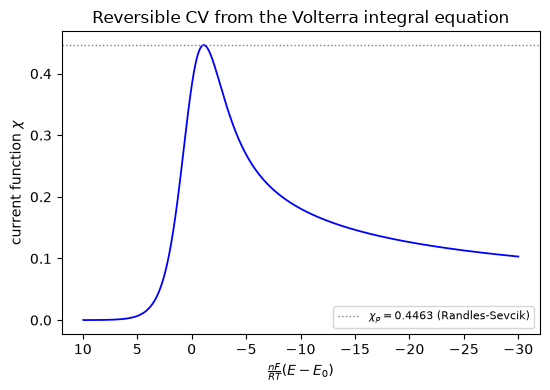

In [8]:
D_TAU = 0.05          # dimensionless time step
N_TAU = 800           # number of steps -> tau up to 40
P0 = 10.0             # start 10 dimensionless units anodic of E0

tau_grid = np.arange(1, N_TAU + 1) * D_TAU
g_rev = 1.0 / (1.0 + np.exp(P0 - tau_grid))       # Nernstian sigmoid RHS

f_rev = solve_volterra_first_kind(g_rev, D_TAU)
chi = np.sqrt(np.pi) * f_rev                      # Nicholson-Shain current function

potential_axis = P0 - tau_grid                    # nF/RT (E - E0), swept cathodic
chi_peak = chi.max()
tau_peak = tau_grid[chi.argmax()]
print(f"peak chi = {chi_peak:.6f}  at  tau = {tau_peak:.3f}")
print(f"Randles-Sevcik constant (Bard & Faulkner): 0.4463")

fig, ax = plt.subplots(figsize=(5.6, 4))
ax.plot(potential_axis, chi, "b-", lw=1.3)
ax.axhline(0.4463, color="0.5", ls=":", lw=1.0,
           label=r"$\chi_p = 0.4463$ (Randles-Sevcik)")
ax.invert_xaxis()                                 # potential swept positive -> negative
ax.set_xlabel(r"$\frac{nF}{RT}(E - E_0)$")
ax.set_ylabel(r"current function $\chi$")
ax.set_title("Reversible CV from the Volterra integral equation")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Validation

We use the strongest available strategy from each category of the authoring
validation policy:

1. **Independent closed-form check (preferred).** The Volterra reversible CV is
   checked against `serm.echem.randles_sevcik_peak_current`. The dimensionless
   peak of $\chi$ should equal the Randles–Ševčík constant $0.4463$, and the
   *dimensional* peak current
   $i_p = nFAc^{*}\sqrt{D\sigma}\,\chi_p$
   (with $\sigma = nFv/RT$) should match the closed-form value to high accuracy.
   The analytic reference in `serm.echem` is computed independently of the
   integral-equation solver, so this is a genuine cross-check.
2. **Convergence check** for the Runge–Kutta integrator: its current transient
   converges to the analytic Cottrell decay, and the error shrinks as the time
   grid is refined (away from the singular instant $\tau\to0$).
3. **Two-implementation cross-check** for SOR (already shown in §2.3): the
   iterative solve reproduces a direct banded Thomas solve of the same system.

Each check ends in an `assert` and prints a `PASS:` line.

In [9]:
# --- Validation 1: Volterra reversible CV vs. Randles-Sevcik (closed form) ---
# Dimensionless peak must equal the Randles-Sevcik constant.
rs_const = 0.4463
rel_chi = abs(chi_peak - rs_const) / rs_const
print(f"peak chi = {chi_peak:.6f},  RS constant = {rs_const},  rel. err = {rel_chi:.2e}")
assert rel_chi < 5e-3, "dimensionless peak does not match Randles-Sevcik constant"

# Dimensional cross-check against serm.echem.randles_sevcik_peak_current.
# i_p = n F A c* sqrt(D sigma) * chi_peak,  sigma = n F v / (R T).
F = echem.F
R = echem.R
n_e, A, D, c_bulk, v, Tk = 1, 1.0, 1e-5, 1e-6, 1.0, 298.15
sigma = n_e * F * v / (R * Tk)
ip_volterra = n_e * F * A * c_bulk * np.sqrt(D * sigma) * chi_peak
ip_closed = echem.randles_sevcik_peak_current(n_e, A, D, c_bulk, v, temperature=Tk)
rel_ip = abs(ip_volterra - ip_closed) / ip_closed
print(f"i_p (Volterra) = {ip_volterra:.6e} A")
print(f"i_p (closed-form Randles-Sevcik) = {ip_closed:.6e} A")
print(f"relative error = {rel_ip:.2e}")
assert rel_ip < 5e-3, "Volterra peak current disagrees with Randles-Sevcik"
print("PASS: Volterra reversible CV reproduces the Randles-Sevcik peak.")

peak chi = 0.446311,  RS constant = 0.4463,  rel. err = 2.39e-05
i_p (Volterra) = 8.495612e-04 A
i_p (closed-form Randles-Sevcik) = 8.495410e-04 A
relative error = 2.39e-05
PASS: Volterra reversible CV reproduces the Randles-Sevcik peak.


In [10]:
# --- Validation 2: Runge-Kutta convergence to Cottrell ---
# Sample the simulated current at a fixed physical time and refine the time grid;
# the relative error against the Cottrell decay must shrink.
def rk_current_at_fixed_tau(n_steps: int, D_M: float = 0.4, tau_target: float = 0.5):
    """Return (|i_sim|, |i_cottrell|) at the step closest to ``tau_target``."""
    hist = rk2_solve(D_M, n_steps)
    fac = 0.5 * np.sqrt(D_M * (n_steps - 1))
    i_sim = (-4.0 * hist[:, 1] + hist[:, 2]) * fac
    k = int(round(tau_target * (n_steps - 1)))
    tau_k = k / (n_steps - 1)
    i_cot = -1.0 / np.sqrt(np.pi * tau_k)
    return abs(i_sim[k]), abs(i_cot)

errs = []
for n_steps in (200, 400, 800):
    i_sim, i_cot = rk_current_at_fixed_tau(n_steps)
    e = abs(i_sim - i_cot) / i_cot
    errs.append(e)
    print(f"n_steps = {n_steps:4d}:  rel. err at tau=0.5 = {e:.3e}")

assert errs[-1] < errs[0], "RK2 error did not decrease under time-grid refinement"
assert errs[-1] < 5e-3, "RK2 current does not match Cottrell within tolerance"
print("PASS: RK2 converges to the Cottrell transient as the grid is refined.")

n_steps =  200:  rel. err at tau=0.5 = 3.447e-04
n_steps =  400:  rel. err at tau=0.5 = 1.646e-04
n_steps =  800:  rel. err at tau=0.5 = 8.025e-05
PASS: RK2 converges to the Cottrell transient as the grid is refined.


In [11]:
# --- Validation 3: SOR vs. direct banded solve (two-implementation cross-check) ---
assert cross_err < 1e-6, "SOR iterate disagrees with the direct banded solve"
print(f"max |SOR - direct banded| = {cross_err:.2e}")
print("PASS: SOR reproduces the direct tridiagonal solve of the implicit step.")

max |SOR - direct banded| = 2.59e-13
PASS: SOR reproduces the direct tridiagonal solve of the implicit step.


## 5. Summary

This chapter implemented three numerical methods that recur throughout
electrochemical simulation, each re-derived from SERM Chapter 4 and validated
independently:

- **Runge–Kutta (RK2 / midpoint).** A second-order explicit integrator for the
  diffusion PDE. Its current transient converges to the Cottrell decay, with the
  error decreasing under time-grid refinement (relative error $<5\times10^{-3}$
  at $\tau=0.5$ for 800 steps).
- **Successive over-relaxation (SOR).** An iterative solver for the implicit
  (backward-Euler) step, with the near-optimal relaxation factor
  $\omega = 2/(1+\pi/(m-2))$. It reproduces a direct banded Thomas solve of the
  same system to machine precision, and its transient matches Cottrell.
- **Volterra integral-equation method (Huber's method).** Solves the
  first-kind convolution equation arising from a Laplace-transform solution,
  yielding a reversible cyclic voltammogram *without spatial discretisation*. Its
  dimensionless peak current reproduces the **Randles–Ševčík constant 0.4463**,
  and the dimensional peak current matches
  `serm.echem.randles_sevcik_peak_current` to a relative error of order
  $10^{-5}$.

The integral-equation machinery is the foundation for the *quasi-reversible* and
*irreversible* cyclic-voltammetry treatments (the second-kind Volterra equation
of SERM §4.7), and the iterative and Runge–Kutta solvers reappear when coupled
homogeneous chemical reactions are introduced in Chapter 13.

<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 3 — Speed and Accuracy: Implicit and Weighted Finite-Difference Schemes](03_speed_and_accuracy.ipynb) | [Chapter 5 — Potential Sweep Methods: the Reversible Voltammogram →](05_potential_sweep_reversible.ipynb) |

[Contents (README)](../README.md)